# DSE4101 Methodology Code — Python translation

- A. Settings  
- B. Dataset simulation  
- C. Methodology  
  - train/test split  
  - one-hot encoding (`model.matrix` analogue)  
  - SMOTE  
  - multi-split LASSO + MLE cleaning step  
  - Random Forest + RFE  
  - XGBoost + RFE  
  - ROC/AUC comparison  
  - feature tables and prediction table


In [ ]:
# Optional: install packages if needed
# !pip install numpy pandas matplotlib scikit-learn imbalanced-learn statsmodels xgboost


In [1]:

# ----------------------------
# A. Settings
# ----------------------------
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 4101
np.random.seed(SEED)


In [2]:

# ----------------------------
# B. Dataset Simulation
# ----------------------------

n_firms = 50
firms = [f"Firm_{i:03d}" for i in range(1, n_firms + 1)]
n_shocks = 5

shock_tbl = pd.DataFrame({
    "shock_id": [1, 2, 3, 4, 5],
    "shock_name": ["Hurricane_A", "Hurricane_B", "Hurricane_C", "Hurricane_D", "Hurricane_E"],
    "year": [2018, 2019, 2020, 2021, 2022],
    "month": [9, 3, 8, 2, 11],
    "day": [14, 22, 10, 6, 19],
    "shock_severity": [0.9, 0.6, 0.7, 1.0, 0.5]
})
shock_tbl["quarter"] = "Q" + (((shock_tbl["month"] - 1) // 3) + 1).astype(str)

years = sorted(shock_tbl["year"].unique())

firm_year_chars = (
    pd.MultiIndex.from_product([firms, years], names=["firm_id", "year"])
    .to_frame(index=False)
    .sort_values(["firm_id", "year"])
    .reset_index(drop=True)
)

firm_year_chars = firm_year_chars.assign(
    branches=np.random.choice(np.arange(0, 6), size=len(firm_year_chars), replace=True),
    direct_impact=np.random.choice([0, 1], size=len(firm_year_chars), replace=True),
    leverage=np.round(np.random.uniform(0.1, 0.8, size=len(firm_year_chars)), 2),
    liquidity=np.round(np.random.uniform(0.5, 3.0, size=len(firm_year_chars)), 2),
    profitability=np.round(np.random.normal(loc=0.08, scale=0.05, size=len(firm_year_chars)), 3),
    employees=np.round(np.random.lognormal(mean=6, sigma=0.6, size=len(firm_year_chars)), 0),
    firm_age=np.random.choice(np.arange(3, 81), size=len(firm_year_chars), replace=True),
    supply_chain_div=np.round(np.random.uniform(0.2, 1.0, size=len(firm_year_chars)), 2),
    prior_disasters=np.random.choice(np.arange(0, 6), size=len(firm_year_chars), replace=True),
    insurance_cover=np.round(np.random.uniform(0.3, 1.0, size=len(firm_year_chars)), 2)
)

sim_data = (
    pd.MultiIndex.from_product([firms, np.arange(1, n_shocks + 1)], names=["firm_id", "shock_id"])
    .to_frame(index=False)
    .merge(shock_tbl, on="shock_id", how="left")
    .merge(firm_year_chars, on=["firm_id", "year"], how="left")
)

sim_data["recovery_days_raw"] = (
    60
    + 2 * sim_data["branches"]
    + 12 * sim_data["direct_impact"]
    + 45 * sim_data["shock_severity"]
    - 10 * sim_data["liquidity"]
    - 12 * sim_data["insurance_cover"]
    - 8 * sim_data["supply_chain_div"]
    - 2 * sim_data["prior_disasters"]
    - 3 * np.log(sim_data["employees"] + 1)
    - 0.15 * sim_data["firm_age"]
    + np.random.normal(loc=0, scale=10, size=len(sim_data))
)

sim_data["recovery_days"] = np.maximum(0, np.round(sim_data["recovery_days_raw"])).astype(int)

sim_data = sim_data[[
    "firm_id",
    "shock_name", "shock_id",
    "year", "month", "day", "quarter",
    "recovery_days",
    "branches", "leverage", "liquidity", "profitability",
    "employees", "firm_age", "supply_chain_div",
    "prior_disasters", "insurance_cover",
    "shock_severity"
]].copy()

for d in [0, 7, 14, 30, 60, 180]:
    sim_data[f"recovered_{d}"] = (sim_data["recovery_days"] <= d).astype(int)

sim_data.head()


,firm_id,shock_name,shock_id,year,month,day,quarter,recovery_days,branches,leverage,...,supply_chain_div,prior_disasters,insurance_cover,shock_severity,recovered_0,recovered_7,recovered_14,recovered_30,recovered_60,recovered_180
0,Firm_001,Hurricane_A,1,2018,9,14,Q3,48,4,0.50,...,0.42,3,0.33,0.9,0,0,0,0,1,1
1,Firm_001,Hurricane_B,2,2019,3,22,Q1,69,5,0.57,...,0.81,2,0.76,0.6,0,0,0,0,0,1
2,Firm_001,Hurricane_C,3,2020,8,10,Q3,40,3,0.39,...,0.64,4,0.93,0.7,0,0,0,0,1,1
3,Firm_001,Hurricane_D,4,2021,2,6,Q1,42,2,0.37,...,0.70,4,0.86,1.0,0,0,0,0,1,1
4,Firm_001,Hurricane_E,5,2022,11,19,Q4,59,0,0.45,...,0.33,0,0.48,0.5,0,0,0,0,1,1


In [3]:
sim_data.shape, sim_data["recovery_days"].describe()

((250, 24),
 count    250.000000
 mean      45.804000
 std       16.804498
 min        0.000000
 25%       34.000000
 50%       45.000000
 75%       57.750000
 max       94.000000
 Name: recovery_days, dtype: float64)

In [4]:

# ----------------------------
# C. Methodology
# ----------------------------

final_data = sim_data.copy()

recovery_outcomes = [
    "recovered_0",
    "recovered_7",
    "recovered_14",
    "recovered_30",
    "recovered_60",
    "recovered_180"
]

predictors = [
    c for c in final_data.columns
    if c not in (
        ["firm_id", "shock_id", "recovery_days", "year", "month", "day", "quarter", "shock_name"]
        + recovery_outcomes
    )
]

predictors


['branches',
 'leverage',
 'liquidity',
 'profitability',
 'employees',
 'firm_age',
 'supply_chain_div',
 'prior_disasters',
 'insurance_cover',
 'shock_severity']

In [5]:

# ----------------------------
# Helper functions
# ----------------------------

def match_closest(sorted_values, target):
    """
    Python analogue of MALDIquant::match.closest for a 1D sorted array.
    Returns the index of the closest value.
    """
    sorted_values = np.asarray(sorted_values, dtype=float)
    return int(np.argmin(np.abs(sorted_values - target)))


def make_model_matrix(df):
    """
    Python analogue of R's model.matrix(~ . - 1, data = ...)
    """
    return pd.get_dummies(df, drop_first=False, dtype=float)


def fit_lasso_1se(X, y, seed=SEED, nfolds=10):
    """
    Approximate the R cv.glmnet(..., alpha = 1, type.measure = 'deviance', family = 'binomial')
    with a manual 1-SE rule in Python.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)

    # Smaller C = stronger penalty = larger lambda
    C_grid = np.logspace(-4, 2, 50)
    cv = StratifiedKFold(n_splits=nfolds, shuffle=True, random_state=seed)

    mean_losses = []
    se_losses = []

    for C in C_grid:
        fold_losses = []
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            clf = LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=C,
                max_iter=5000,
                random_state=seed
            )
            clf.fit(X_tr, y_tr)
            prob = clf.predict_proba(X_val)[:, 1]
            fold_losses.append(log_loss(y_val, prob, labels=[0, 1]))

        mean_losses.append(np.mean(fold_losses))
        se_losses.append(np.std(fold_losses, ddof=1) / np.sqrt(len(fold_losses)))

    mean_losses = np.asarray(mean_losses)
    se_losses = np.asarray(se_losses)

    best_idx = int(np.argmin(mean_losses))
    threshold = mean_losses[best_idx] + se_losses[best_idx]

    # 1-SE rule: choose the strongest penalty within 1 SE of the minimum loss
    eligible = np.where(mean_losses <= threshold)[0]
    chosen_idx = int(eligible[0])  # smallest C among eligible => strongest penalty

    chosen_C = float(C_grid[chosen_idx])

    final_fit = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=chosen_C,
        max_iter=5000,
        random_state=seed
    )
    final_fit.fit(X, y)

    return {
        "model": final_fit,
        "C_grid": C_grid,
        "mean_losses": mean_losses,
        "se_losses": se_losses,
        "C_best": float(C_grid[best_idx]),
        "C_1se": chosen_C
    }


def tune_rf_max_features(X, y, seed=SEED):
    """
    Mimics the ranger mtry grid in the R script:
    unique(c(floor(sqrt(p)), floor(p / 2), p))
    """
    p = X.shape[1]
    mtry_vals = sorted(set([
        max(1, min(p, int(np.floor(np.sqrt(p))))),
        max(1, min(p, int(np.floor(p / 2)))),
        max(1, min(p, p))
    ]))

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    best_mtry = mtry_vals[0]
    best_auc = -np.inf

    for mtry in mtry_vals:
        clf = RandomForestClassifier(
            n_estimators=300,
            max_features=mtry,
            random_state=seed,
            n_jobs=-1
        )
        auc = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc", n_jobs=None).mean()
        if auc > best_auc:
            best_auc = auc
            best_mtry = mtry

    return best_mtry, best_auc


def get_xgb_base_estimator(seed=SEED):
    """
    Fixed xgboost specification used inside the RFE block in the R script.
    """
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        gamma=0,
        colsample_bytree=0.8,
        min_child_weight=1,
        subsample=0.8,
        random_state=seed,
        n_jobs=-1,
        use_label_encoder=False
    )


def get_xgb_final_estimator(seed=SEED):
    """
    Final xgboost model used after selecting variables.
    """
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        n_jobs=-1,
        use_label_encoder=False
    )


In [8]:

# ----------------------------
# Main running function
# ----------------------------

def model(data, outcome, predictors, seed=SEED):
    ## ----------------
    ## I. Prepare Data
    ## ----------------

    # 1. Drop non-feature variables and build model frame
    model_df = data[[outcome] + predictors].copy()

    char_cols = model_df.select_dtypes(include=["object"]).columns.tolist()
    for col in char_cols:
        model_df[col] = model_df[col].astype("category")

    model_df = model_df.dropna().copy()
    model_df["y"] = pd.Categorical(model_df[outcome], categories=[0, 1])
    model_df = model_df.drop(columns=[outcome])

    # 2. Split data into training and testing
    train_df, test_df = train_test_split(
        model_df,
        train_size=0.8,
        stratify=model_df["y"],
        random_state=seed
    )

    y_train = train_df["y"].astype(int).reset_index(drop=True)
    x_train = make_model_matrix(train_df.drop(columns=["y"])).reset_index(drop=True)

    y_test = test_df["y"].astype(int).reset_index(drop=True)
    x_test = make_model_matrix(test_df.drop(columns=["y"])).reset_index(drop=True)

    # align test columns to train columns, just like model.matrix consistency
    x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

    # 3. Apply SMOTE
    minority_n = int(y_train.value_counts().min())
    K_use = max(1, min(5, minority_n - 1))

    smoted = SMOTE(k_neighbors=K_use, random_state=seed)
    x_smoted_array, y_smoted_array = smoted.fit_resample(x_train, y_train)

    x_smoted = pd.DataFrame(x_smoted_array, columns=x_train.columns)
    y_smoted = pd.Series(y_smoted_array, name="y").astype(int)

    # 4. Prepare RFE labels for Random Forest / XGBoost
    y_smoted_rfe = pd.Series(np.where(y_smoted == 1, "yes", "no"), name="y")
    rfe_sizes = list(range(1, x_smoted.shape[1] + 1))

    ## ----------------
    ## II. Train Model
    ## ----------------

    ## =========================
    ## 1. Multi-split LASSO (from Costa and Baker, 2021)
    ## =========================

    var_names = x_smoted.columns.tolist()
    VIM = pd.DataFrame({"Variables": var_names, "VIM": 0.0})
    p_final = {v: [] for v in var_names}
    e_final = {v: [] for v in var_names}
    s_final = {v: [] for v in var_names}

    smoted_data = x_smoted.copy()
    smoted_data["y"] = y_smoted.values

    B = 10  # Number of splits

    rng = np.random.default_rng(seed)

    for i in range(B):
        beta_lasso = pd.DataFrame({"Variables": var_names, "Multiplier": 0})
        raw = pd.DataFrame({
            "Variables": var_names,
            "p_raw": 1.0,
            "estimate_raw": 0.0,
            "error_raw": 0.0
        })

        # 1. randomly split the data into screening and cleaning sets
        screen_rows = rng.choice(np.arange(len(smoted_data)), size=int(np.floor(0.5 * len(smoted_data))), replace=False)
        screen = smoted_data.iloc[screen_rows].copy().reset_index(drop=True)

        clean_all = smoted_data.drop(index=screen_rows).copy().reset_index(drop=True)
        clean = clean_all.copy()

        x_screen = screen.drop(columns=["y"]).to_numpy()
        y_screen = screen["y"].to_numpy()

        # 2. Use LASSO on the screening set
        fit = fit_lasso_1se(x_screen, y_screen, seed=seed + i, nfolds=10)
        tmp_coeffs = pd.Series(fit["model"].coef_.ravel(), index=var_names)

        coefs = pd.DataFrame({
            "name": tmp_coeffs.index,
            "coefficient": tmp_coeffs.values
        })
        coefs = coefs.loc[coefs["coefficient"] != 0].reset_index(drop=True)

        for k in range(len(beta_lasso)):
            for j in range(len(coefs)):
                if coefs.loc[j, "name"] == beta_lasso.loc[k, "Variables"]:
                    beta_lasso.loc[k, "Multiplier"] = 1

        # Get all coefficients with Beta > 0, otherwise remove from clean
        drop_vars = beta_lasso.loc[beta_lasso["Multiplier"] == 0, "Variables"].tolist()
        clean = clean.drop(columns=drop_vars, errors="ignore")

        df_clean = clean.copy()

        # Fit a logistic regression model using MLE with the selected features
        if df_clean.shape[1] > 1:
            X_clean = sm.add_constant(df_clean.drop(columns=["y"]), has_constant="add")
            y_clean = df_clean["y"].astype(int)

            try:
                mle_fit = sm.GLM(y_clean, X_clean, family=sm.families.Binomial()).fit()
                summary_coef = mle_fit.summary2().tables[1]
            except Exception:
                mle_fit = None
                summary_coef = pd.DataFrame()
        else:
            mle_fit = None
            summary_coef = pd.DataFrame()

        # Obtain the raw p-values for the predictors selected with the MLE
        for j in range(len(raw)):
            var_j = raw.loc[j, "Variables"]
            if not summary_coef.empty and (var_j in summary_coef.index):
                raw.loc[j, "p_raw"] = summary_coef.loc[var_j, "P>|z|"]
                raw.loc[j, "estimate_raw"] = summary_coef.loc[var_j, "Coef."]
                raw.loc[j, "error_raw"] = summary_coef.loc[var_j, "Std.Err."]

        # Calculate the final p-value
        correction_factor = max(df_clean.shape[1] - 1, 1)
        p_corr = [min(raw.loc[j, "p_raw"] * correction_factor, 1) for j in range(len(raw))]

        for j, var_j in enumerate(raw["Variables"]):
            p_final[var_j].append(float(p_corr[j]))
            e_final[var_j].append(float(raw.loc[j, "estimate_raw"]))
            s_final[var_j].append(float(raw.loc[j, "error_raw"]))

        # calculate the VIM
        for j in range(len(coefs)):
            for k in range(len(VIM)):
                if coefs.loc[j, "name"] == VIM.loc[k, "Variables"]:
                    VIM.loc[k, "VIM"] = VIM.loc[k, "VIM"] + 1 / B

    # Calculate the p-values, estimates, and standard errors
    df_summary = pd.DataFrame({"Variables": var_names, "p": 1.0})

    for i in range(len(var_names)):
        var_i = var_names[i]
        p_sorted = np.sort(np.asarray(p_final[var_i], dtype=float))

        deltas = np.linspace(0.05, 1.00, 96)
        quantiles = np.quantile(p_sorted, deltas)

        quantiles_df = pd.DataFrame({
            "d": deltas,
            "q": quantiles,
            "q_d": quantiles / deltas
        })

        min_row = quantiles_df.loc[quantiles_df["q_d"].idxmin()]
        min_delta = float(min_row["d"])
        q_min_delta = float(min_row["q"])

        summ_delta = min(4 * q_min_delta / min_delta, 1)
        summ_index = match_closest(p_sorted, summ_delta)
        p_summ = p_sorted[summ_index]

        df_summary.loc[i, "p"] = p_summ

    # Results from the multi-split algorithm
    results = VIM.copy()
    results["pValue"] = df_summary["p"].values
    results["Code"] = 0
    results["Check"] = 0

    for i in range(len(results)):
        results.loc[i, "Check"] = int(
            (results.loc[i, "VIM"] > 0.75) and (results.loc[i, "pValue"] < 0.05)
        )

    multisplit_final_vars = results.loc[results["Check"] == 1, "Variables"].tolist()

    ## =========================
    ## 2. Random Forest + RFE
    ## =========================

    best_mtry, best_rf_auc = tune_rf_max_features(x_smoted, y_smoted_rfe, seed=seed)

    rf_estimator = RandomForestClassifier(
        n_estimators=300,
        max_features=best_mtry,
        random_state=seed,
        n_jobs=-1
    )

    rf_rfe = RFECV(
        estimator=rf_estimator,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring="roc_auc",
        min_features_to_select=1,
        n_jobs=None
    )
    rf_rfe.fit(x_smoted, y_smoted)

    rf_selected_vars = x_smoted.columns[rf_rfe.support_].tolist()
    if (rf_selected_vars is None) or (len(rf_selected_vars) == 0):
        rf_selected_vars = x_smoted.columns.tolist()

    rf_fit = RandomForestClassifier(
        n_estimators=500,
        random_state=seed,
        n_jobs=-1
    )
    rf_fit.fit(x_smoted[rf_selected_vars], y_smoted)
    rf_prob = rf_fit.predict_proba(x_test[rf_selected_vars])

    ## =========================
    ## 3. XGBoost + RFE
    ## =========================

    xgb_rfe_estimator = get_xgb_base_estimator(seed=seed)

    xgb_rfe = RFECV(
        estimator=xgb_rfe_estimator,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring="roc_auc",
        min_features_to_select=1,
        n_jobs=None
    )
    xgb_rfe.fit(x_smoted, y_smoted)

    xgb_selected_vars = x_smoted.columns[xgb_rfe.support_].tolist()
    if (xgb_selected_vars is None) or (len(xgb_selected_vars) == 0):
        xgb_selected_vars = x_smoted.columns.tolist()

    xgb_fit = get_xgb_final_estimator(seed=seed)
    xgb_fit.fit(x_smoted[xgb_selected_vars], y_smoted)

    ## ----------------
    ## III. Testing Model
    ## ----------------

    ## 1. Multi-split LASSO using Logistic Regression
    if len(multisplit_final_vars) > 0:
        mle_train = smoted_data[multisplit_final_vars + ["y"]].copy()
        mle_test = x_test[multisplit_final_vars].copy()

        X_mle_train = sm.add_constant(mle_train.drop(columns=["y"]), has_constant="add")
        y_mle_train = mle_train["y"].astype(int)

        X_mle_test = sm.add_constant(mle_test, has_constant="add")
        X_mle_test = X_mle_test.reindex(columns=X_mle_train.columns, fill_value=1.0)

        multisplit_mle = sm.GLM(y_mle_train, X_mle_train, family=sm.families.Binomial()).fit()
        pred_multisplit = multisplit_mle.predict(X_mle_test)
    else:
        mle_train = pd.DataFrame({"y": smoted_data["y"].astype(int)})
        X_intercept = pd.DataFrame({"const": np.ones(len(mle_train))})
        multisplit_mle = sm.GLM(mle_train["y"], X_intercept, family=sm.families.Binomial()).fit()
        pred_multisplit = np.repeat(float(multisplit_mle.predict(pd.DataFrame({"const": [1]}))[0]), len(x_test))

    ## 2. Random Forest with RFE
    pred_rf = rf_prob[:, list(rf_fit.classes_).index(1)]

    ## 3. XGBoost with RFE
    pred_xgb = xgb_fit.predict_proba(x_test[xgb_selected_vars])[:, 1]

    ## ----------------
    ## IV. ROC Curves
    ## ----------------

    auc_table = pd.DataFrame({
        "Model": ["Multi-split LASSO + MLE", "Random Forest", "XGBoost"],
        "AUC": [
            roc_auc_score(y_test, pred_multisplit),
            roc_auc_score(y_test, pred_rf),
            roc_auc_score(y_test, pred_xgb)
        ]
    })

    roc_dict = {
        f"Multi-split LASSO + MLE (AUC = {roc_auc_score(y_test, pred_multisplit):.3f})": pred_multisplit,
        f"Random Forest (AUC = {roc_auc_score(y_test, pred_rf):.3f})": pred_rf,
        f"XGBoost (AUC = {roc_auc_score(y_test, pred_xgb):.3f})": pred_xgb
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    for label, pred in roc_dict.items():
        fpr, tpr, _ = roc_curve(y_test, pred)
        ax.plot(fpr, tpr, linewidth=1.5, label=label)

    ax.plot([0, 1], [0, 1], linestyle="dashed")
    ax.set_title("ROC Curve Comparison")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(False)

    ## ----------------
    ## V. Feature Tables
    ## ----------------

    if len(multisplit_final_vars) > 0:
        multisplit_feature_table = pd.DataFrame({
            "Model": "Multi-split LASSO + MLE",
            "Feature": multisplit_final_vars,
            "Score": results.set_index("Variables").loc[multisplit_final_vars, "VIM"].values,
            "pValue": results.set_index("Variables").loc[multisplit_final_vars, "pValue"].values
        })
    else:
        multisplit_feature_table = pd.DataFrame(columns=["Model", "Feature", "Score", "pValue"])

    rf_feature_table = pd.DataFrame({
        "Model": "Random Forest",
        "Feature": rf_selected_vars,
        "Score": rf_fit.feature_importances_,
        "pValue": np.nan
    }).sort_values("Score", ascending=False).reset_index(drop=True)

    booster = xgb_fit.get_booster()
    xgb_imp_dict = booster.get_score(importance_type="gain")
    xgb_feature_table = pd.DataFrame({
        "Model": "XGBoost",
        "Feature": list(xgb_imp_dict.keys()),
        "Score": list(xgb_imp_dict.values()),
        "pValue": np.nan
    })

    feature_table = pd.concat(
        [multisplit_feature_table, rf_feature_table, xgb_feature_table],
        axis=0,
        ignore_index=True
    )

    prediction_table = pd.DataFrame({
        "y_true": y_test,
        "pred_multisplit": pred_multisplit,
        "pred_rf": pred_rf,
        "pred_xgb": pred_xgb
    })

    return {
        "train_df": train_df,
        "test_df": test_df,
        "x_smoted": x_smoted,
        "x_test": x_test,
        "y_smoted": y_smoted,
        "y_test": y_test,

        "multisplit_results": results,
        "multisplit_final_vars": multisplit_final_vars,
        "multisplit_mle": multisplit_mle,

        "rf_rfe": rf_rfe,
        "rf_selected_vars": rf_selected_vars,
        "rf_fit": rf_fit,

        "xgb_rfe": xgb_rfe,
        "xgb_selected_vars": xgb_selected_vars,
        "xgb_fit": xgb_fit,

        "prediction_table": prediction_table,
        "auc_table": auc_table,
        "roc_plot": fig,
        "feature_table": feature_table
    }


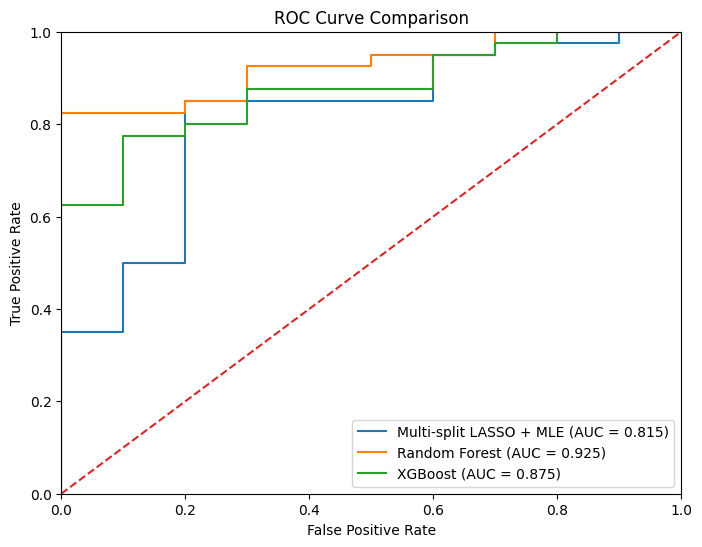

In [9]:
out = model(final_data, "recovered_60", predictors)

In [10]:
out["multisplit_results"].head()

,Variables,VIM,pValue,Code,Check
0,branches,1.0,0.015408,0,1
1,leverage,0.1,1.000000,0,0
2,liquidity,1.0,0.000366,0,1
3,profitability,0.0,1.000000,0,0
4,employees,1.0,0.003535,0,1


In [11]:
out["multisplit_final_vars"], out["rf_selected_vars"], out["xgb_selected_vars"]

(['branches', 'liquidity', 'employees', 'shock_severity'],
 ['branches',
  'leverage',
  'liquidity',
  'profitability',
  'employees',
  'firm_age',
  'supply_chain_div',
  'prior_disasters',
  'insurance_cover',
  'shock_severity'],
 ['branches',
  'leverage',
  'liquidity',
  'employees',
  'firm_age',
  'supply_chain_div',
  'prior_disasters',
  'insurance_cover',
  'shock_severity'])

In [12]:
out["auc_table"]

,Model,AUC
0,Multi-split LASSO + MLE,0.815
1,Random Forest,0.925
2,XGBoost,0.875


In [13]:
out["feature_table"].head(20)

,Model,Feature,Score,pValue
0,Multi-split LASSO + MLE,branches,1.000000,0.015408
1,Multi-split LASSO + MLE,liquidity,1.000000,0.000366
2,Multi-split LASSO + MLE,employees,1.000000,0.003535
3,Multi-split LASSO + MLE,shock_severity,1.000000,0.000003
4,Random Forest,shock_severity,0.224512,NaN
5,Random Forest,liquidity,0.164465,NaN
6,Random Forest,employees,0.126980,NaN
7,Random Forest,branches,0.098251,NaN
8,Random Forest,supply_chain_div,0.075727,NaN
9,Random Forest,insurance_cover,0.074115,NaN


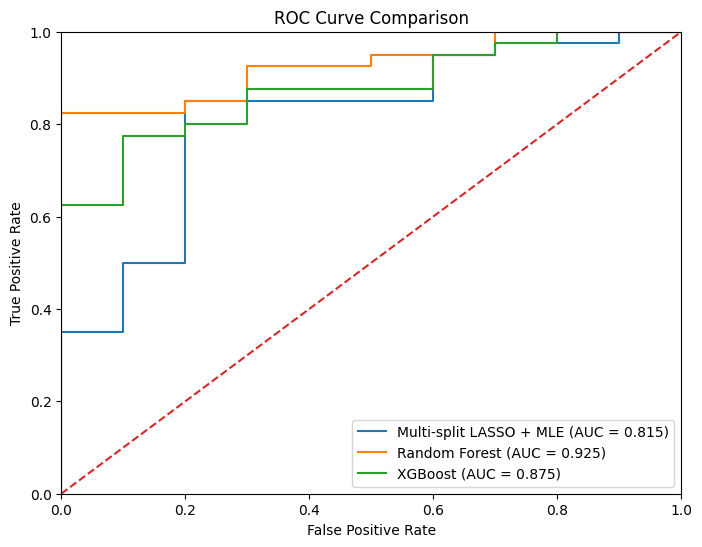

In [14]:
out["roc_plot"]

In [15]:
out["prediction_table"].head()

,y_true,pred_multisplit,pred_rf,pred_xgb
0,0,0.062783,0.306,0.204506
1,1,0.970891,0.712,0.730468
2,1,0.940486,0.876,0.977028
3,1,0.061190,0.354,0.174590
4,1,0.974706,0.934,0.983550
